In [1]:
import torch
from torch import nn
from d2l import torch as d2l
from d2l.torch import Animator

batch_size = 256
train_iter,test_iter = d2l.load_data_fashion_mnist(batch_size)

In [2]:
#初始化模型参数
num_inputs,num_outputs,num_hiddens = 784,10,256
W1 = nn.Parameter(torch.randn(num_inputs,num_outputs,requires_grad=True)*0.01) #nn.Parameter 只是一个标识用的，增加代码的可读性
b1 = nn.Parameter(torch.zeros(num_hiddens,requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens,num_outputs,requires_grad=True)*0.01)
b2 = nn.Parameter(torch.zeros(num_outputs,requires_grad=True))
params = [W1,b1,W2,b2]

In [3]:
#激活函数
def relu(X):
    a = torch.zeros_like()
    return torch.max(X,a)

In [4]:
#模型
def net(X):
    X = X.reshape(-1,num_inputs)
    H = relu(X@W1+b1)#这里的@代表矩阵的乘法
    return (H@W2+b2)

In [5]:
#损失函数
loss = nn.CrossEntropyLoss(reduction='None')

In [6]:
class Accumulator:
    #在n个变量上累加
    def __init__(self,n):
        self.data = [0.0]*n#生成一个n个元素的列表
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data([0.0]*len(len(self.data)))
    def __getitem__(self,idx):
        return self.data[idx]
        
# 分类精度,数据集的某一批的分类的准确率
def accuracy(y_hat, y):
    # 计算预测正确的数量
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
       # print(y_hat.argmax(axis=1))
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

# 计算数据集上的精度
def evaluate_accuracy(net, data_iter):
    # 计算指定数据集上的精度
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式 训练模式下：Batch Normalization 层会根据当前 mini-batch 的统计数据（均值和方差）进行归一化。评估模式下：Batch Normalization 层使用整个训练过程中的全局统计数据（均值和方差）进行归一化。
    metric = Accumulator(2)  # 正确预测数，预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0]/metric[1]


def train_epoch_ch3(net, train_iter, loss, updater):
    # 训练模型一轮
    # 将模型设置为训练模式，这里的ch3是第三章的意思，李沐已经把他封装在d2l库中了
    if isinstance(net, torch.nn.Module):
        net.train()  # 训练模式下：Batch Normalization 层会根据当前 mini-batch 的统计数据（均值和方差）进行归一化。评估模式下：Batch Normalization 层使用整个训练过程中的全局统计数据（均值和方差）进行归一化。
    metric = Accumulator(3)  # 列表三个元素依次是训练损失总和，训练准确度总和，样本数
    for X, y in train_iter:
        # 计算梯度并且更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用pytorch的内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0]/metric[2], metric[1]/metric[2]

def train_ch3(net,train_iter,test_iter,loss,num_epochs,updater):
    animator = Animator(xlabel='epoch',xlim=[1,num_epochs],ylim=[0.3,0.9],legend=['train loss','train acc','test acc'])#训练损失函数，训练准确性，测试准确性
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net,train_iter,loss,updater)
        test_acc = evaluate_accuracy(net,test_iter)
        animator.add(epoch+1,train_metrics+(test_acc,))
    train_loss,train_acc = train_metrics
    assert train_loss<0.5,train_loss
    assert train_acc <= 1 and train_acc>0.7,train_acc
    assert test_acc <= 1 and test_acc >0.7,test_acc

RuntimeError: The size of tensor a (10) must match the size of tensor b (256) at non-singleton dimension 1

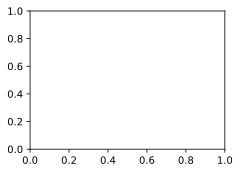

In [7]:
#训练
num_epochs,lr = 10,0.1
updater = torch.optim.SGD(params,lr=lr)
train_ch3(net,train_iter,test_iter,loss,num_epochs,updater)